# Analisis Pola Penjualan Produk Kosmetik TIE Lameila di TokoPedia

Tujuan :
1. identifikasi pola distribusi penjualan (harga,rating, jumlah terjual, lokasi)
2. deteksi anomali harga dan pola transaksi mencurigakan
3. mengelompokkan penjual berdasarkan tingkat risiko menggunakan clustering
4. text mining untuk mencari keyword plg sering digunakan dlm penulisan deskripsi penjualan lameila
5. association rule mining untuk menemukan keterikatan antar var harga, rating, lokasi, dan kategori risiko

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import pandas as dataframe
import string
import nltk
import matplotlib as mpl
import matplotlib.pyplot as plt
import re
import collections
import sys
import os
import numpy
import seaborn as sns
import csv
from collections import OrderedDict
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from IPython.display import display
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from pylab import figure, axes, pie, title, show
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd

df = pd.read_excel('/content/data lameila.xlsx', sheet_name='tokped lam')
df.head(1)

,contents href,Deskripsi,H078hzBk9mrpZdtHF5MqWA== src,line-clamp-2,font-medium 2,+gFwr+QKBmB9gJvF845AkA== src,flex-none,truncate,si3CNdiG8AR0EaXvf6bFbQ==,ml-[3px],875rem] href,h-4
0,https://www.tokopedia.com/mupdaily2/lameila-4-...,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,https://p16-images-sign-sg.tokopedia-static.ne...,Lameila 4 Color Avocado Eyeshadow Disk Matte S...,7900,https://lf-web-assets.tokopedia-static.net/obj...,5.0,30+ terjual,jusep17,Bandung,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   contents href                 211 non-null    object 
 1   Deskripsi                     211 non-null    object 
 2   H078hzBk9mrpZdtHF5MqWA== src  189 non-null    object 
 3   line-clamp-2                  211 non-null    object 
 4   font-medium 2                 211 non-null    int64  
 5   +gFwr+QKBmB9gJvF845AkA== src  75 non-null     object 
 6   flex-none                     98 non-null     float64
 7   truncate                      125 non-null    object 
 8   si3CNdiG8AR0EaXvf6bFbQ==      211 non-null    object 
 9   ml-[3px]                      211 non-null    object 
 10  875rem] href                  0 non-null      float64
 11  h-4                           0 non-null      float64
dtypes: float64(3), int64(1), object(8)
memory usage: 19.9+ KB


In [ ]:
df = df.rename(columns={
    'contents href': 'Link Produk',
    'line-clamp-2': 'Nama Produk',
    'font-medium 2': 'Harga',
    'flex-none': 'Rating',
    'truncate': 'Jumlah Terjual',
    'si3CNdiG8AR0EaXvf6bFbQ==': 'Nama Toko',
    'ml-[3px]': 'Kota'
})

In [ ]:
df.head(1)

,Link Produk,Deskripsi,H078hzBk9mrpZdtHF5MqWA== src,Nama Produk,Harga,+gFwr+QKBmB9gJvF845AkA== src,Rating,Jumlah Terjual,Nama Toko,Kota,875rem] href,h-4
0,https://www.tokopedia.com/mupdaily2/lameila-4-...,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,https://p16-images-sign-sg.tokopedia-static.ne...,Lameila 4 Color Avocado Eyeshadow Disk Matte S...,7900,https://lf-web-assets.tokopedia-static.net/obj...,5.0,30+ terjual,jusep17,Bandung,NaN,NaN


In [ ]:
df = df.drop(columns={'H078hzBk9mrpZdtHF5MqWA== src', '+gFwr+QKBmB9gJvF845AkA== src', '875rem] href', 'h-4'})

In [ ]:
df.head(1)

,Link Produk,Deskripsi,Nama Produk,Harga,Rating,Jumlah Terjual,Nama Toko,Kota
0,https://www.tokopedia.com/mupdaily2/lameila-4-...,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,Lameila 4 Color Avocado Eyeshadow Disk Matte S...,7900,5.0,30+ terjual,jusep17,Bandung


In [ ]:
df['Harga'] = (
    df['Harga']
      .astype(str)
      .str.replace(r'[^0-9]', '', regex=True)
      .astype(int)
)

In [ ]:
df

,Link Produk,Deskripsi,Nama Produk,Harga,Rating,Jumlah Terjual,Nama Toko,Kota
0,https://www.tokopedia.com/mupdaily2/lameila-4-...,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,Lameila 4 Color Avocado Eyeshadow Disk Matte S...,7900,5.0,30+ terjual,jusep17,Bandung
1,https://www.tokopedia.com/sanimeila/lameila-cl...,LAMEILA Cleansing Makeup Remover Moisturize . ...,Lameila Cleansing Make Up Remover Moisturize M...,18900,5.0,4 terjual,Sanimeila,Jakarta Barat
2,https://www.tokopedia.com/xolabel/lameila-mois...,LAMEILA Cleansing Makeup Remover Moisturize . ...,Lameila Moisturizer Lip Mask Blm Mask Pelembab...,12300,5.0,12 terjual,XO Label,Kab. Tangerang
3,https://www.tokopedia.com/pusatskincaresurabay...,KEUNGGULAN : * Mudah di aplikasikan dengan apl...,"Lameila Concealer, Concealer",10000,4.6,250+ terjual,Pusat Skincare Surabaya,Surabaya
4,https://www.tokopedia.com/belbul21/lameila-lig...,manfaat : ~ memudahkan juga menerapkan dala me...,Lameila~Light And Soft Concelear,8000,NaN,12 terjual,belbul21,Denpasar
...,...,...,...,...,...,...,...,...
206,https://www.tokopedia.com/mupdaily2/lameila-be...,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,Lameila Bedak Tabur Loose Powder Oil Control w...,42000,1.0,7 terjual,jusep17,Bandung
207,https://www.tokopedia.com/glowris/cod-lameila-...,LAMEILA FACE STICK CONCEALER 2 IN 1\n\nLameila...,[ COD ] Lameila Face Stick 2in1 Concealer Stic...,10185,4.7,13 terjual,Glowris Store,Kab. Bogor
208,https://www.tokopedia.com/neli-merdihilac/lame...,SIAP LANGSUNG KIRIM BISA COD\nBEAUTY MAKE UP S...,Lameila 1 Set Make up Sultan 30in1 alat makeup...,338520,NaN,1 terjual,YAYINEW,Depok
209,https://www.tokopedia.com/herliza-julvita-idw8...,Keunggulan :BB Cream ini dengan tekstur ringan...,LML LAMEIL SVML 5137 Air Cushion BB Cream Conc...,19998,NaN,1 terjual,HERLIZA JULVITA-iDw8aHEYpI,Jakarta Pusat


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Link Produk     211 non-null    object 
 1   Deskripsi       211 non-null    object 
 2   Nama Produk     211 non-null    object 
 3   Harga           211 non-null    int64  
 4   Rating          98 non-null     float64
 5   Jumlah Terjual  125 non-null    object 
 6   Nama Toko       211 non-null    object 
 7   Kota            211 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 13.3+ KB


In [ ]:
import numpy as np
import re

def parse_sold(x):
    x = str(x).lower().strip()

    # hapus karakter tidak penting
    x = x.replace('+','').replace('terjual','').replace(' ','')

    # jika mengandung rb (contoh: "10rb")
    if 'rb' in x:
        num = re.sub(r'[^0-9]', '', x)
        if num.isdigit():
            return int(num) * 1000

    # angka biasa
    num = re.sub(r'[^0-9]', '', x)
    if num.isdigit():
        return int(num)

    return np.nan

df['Jumlah Terjual'] = df['Jumlah Terjual'].apply(parse_sold).astype('Int64')
df.head()

,Link Produk,Deskripsi,Nama Produk,Harga,Rating,Jumlah Terjual,Nama Toko,Kota
0,https://www.tokopedia.com/mupdaily2/lameila-4-...,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,Lameila 4 Color Avocado Eyeshadow Disk Matte S...,7900,5.0,30,jusep17,Bandung
1,https://www.tokopedia.com/sanimeila/lameila-cl...,LAMEILA Cleansing Makeup Remover Moisturize . ...,Lameila Cleansing Make Up Remover Moisturize M...,18900,5.0,4,Sanimeila,Jakarta Barat
2,https://www.tokopedia.com/xolabel/lameila-mois...,LAMEILA Cleansing Makeup Remover Moisturize . ...,Lameila Moisturizer Lip Mask Blm Mask Pelembab...,12300,5.0,12,XO Label,Kab. Tangerang
3,https://www.tokopedia.com/pusatskincaresurabay...,KEUNGGULAN : * Mudah di aplikasikan dengan apl...,"Lameila Concealer, Concealer",10000,4.6,250,Pusat Skincare Surabaya,Surabaya
4,https://www.tokopedia.com/belbul21/lameila-lig...,manfaat : ~ memudahkan juga menerapkan dala me...,Lameila~Light And Soft Concelear,8000,NaN,12,belbul21,Denpasar


In [ ]:
df['Rating'] = (
    df['Rating']
    .astype(str)
    .str.extract(r'([\d\.]+)')
    .astype(float))

In [ ]:
df['Kota'] = df['Kota'].astype(str).str.strip()

In [ ]:
df.isna().sum()

,0
Link Produk,0
Deskripsi,0
Nama Produk,0
Harga,0
Rating,113
Jumlah Terjual,86
Nama Toko,0
Kota,0


In [ ]:
df['Jumlah Terjual'] = df['Jumlah Terjual'].fillna(0).astype(int)

In [ ]:
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

In [ ]:
df.isnull().sum()

,0
Link Produk,0
Deskripsi,0
Nama Produk,0
Harga,0
Rating,0
Jumlah Terjual,0
Nama Toko,0
Kota,0


In [ ]:
df.describe()

,Harga,Rating,Jumlah Terjual
count,2.110000e+02,211.000000,211.000000
mean,4.071944e+04,4.808294,93.654028
std,1.943940e+05,0.503360,692.259433
min,4.450000e+02,1.000000,0.000000
25%,8.840000e+03,4.950000,0.000000
50%,1.300000e+04,4.950000,1.000000
75%,1.845000e+04,4.950000,4.000000
max,2.450000e+06,5.000000,8000.000000


distribusi harga produk

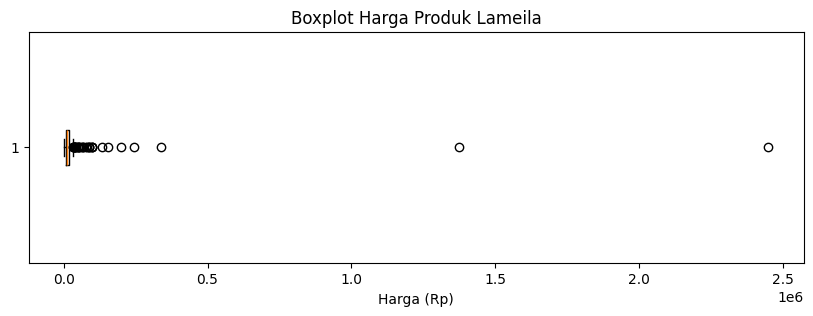

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.boxplot(df['Harga'].dropna(), vert=False)
plt.title("Boxplot Harga Produk Lameila")
plt.xlabel("Harga (Rp)")
plt.show()

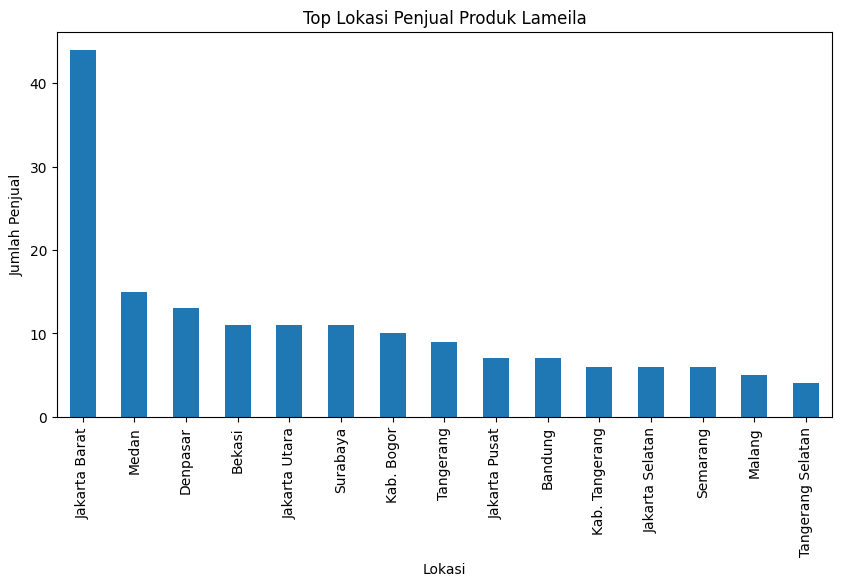

In [ ]:
df['Kota'].value_counts().head(15).plot(kind='bar', figsize=(10,5))
plt.title("Top Lokasi Penjual Produk Lameila")
plt.xlabel("Lokasi")
plt.ylabel("Jumlah Penjual")
plt.show()

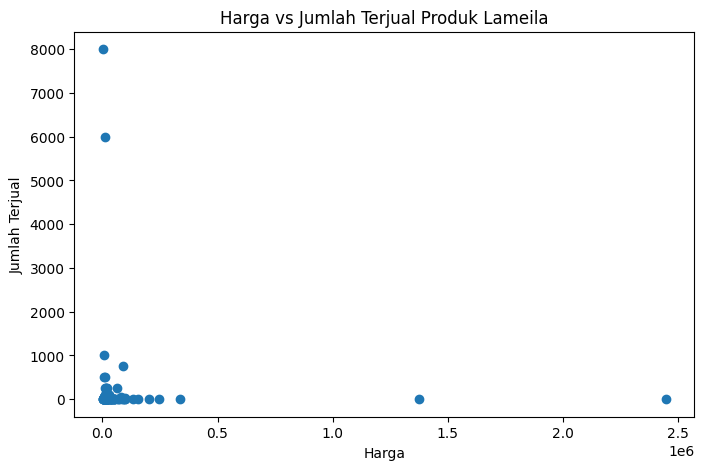

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Harga'], df['Jumlah Terjual'])
plt.title("Harga vs Jumlah Terjual Produk Lameila")
plt.xlabel("Harga")
plt.ylabel("Jumlah Terjual")
plt.show()

/tmp/ipython-input-3699089238.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Harga'], bins=10))['Rating'].mean().plot(kind='bar', figsize=(10,5))


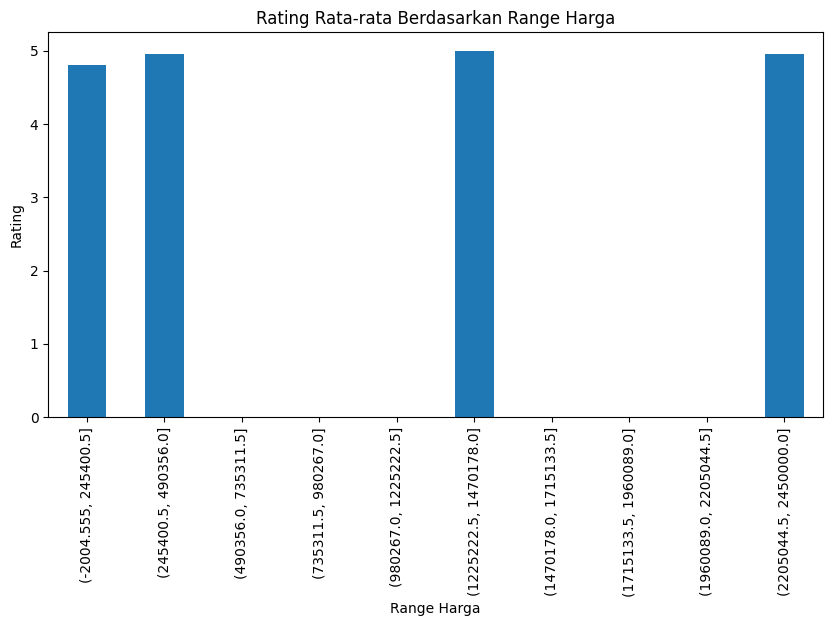

In [ ]:
df.groupby(pd.cut(df['Harga'], bins=10))['Rating'].mean().plot(kind='bar', figsize=(10,5))
plt.title("Rating Rata-rata Berdasarkan Range Harga")
plt.xlabel("Range Harga")
plt.ylabel("Rating")
plt.show()

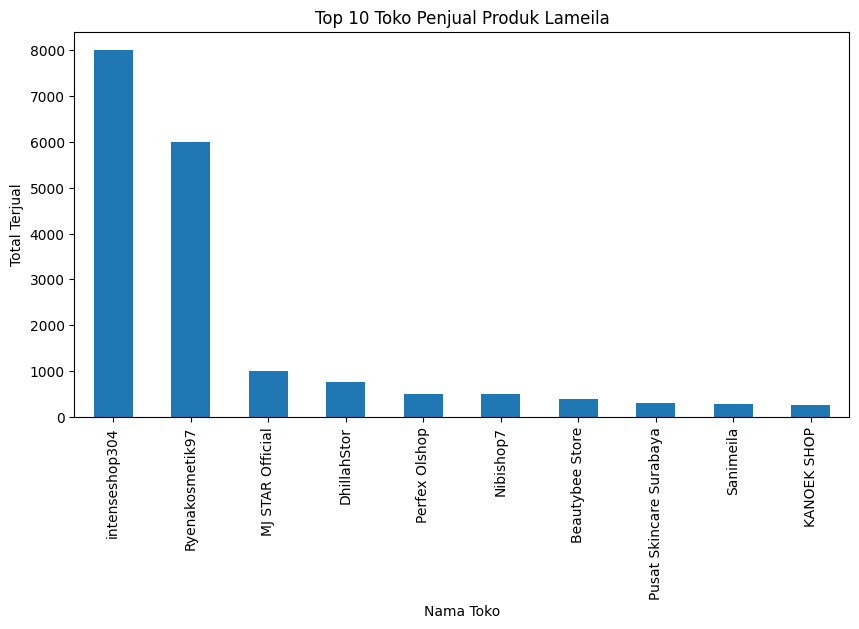

In [ ]:
top_seller = df.groupby('Nama Toko')['Jumlah Terjual'].sum().sort_values(ascending=False).head(10)

top_seller.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Toko Penjual Produk Lameila")
plt.xlabel("Nama Toko")
plt.ylabel("Total Terjual")
plt.show()


In [ ]:
Q1 = df['Harga'].quantile(0.25)
Q3 = df['Harga'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

lower_limit, upper_limit

(np.float64(-5575.0), np.float64(32865.0))

In [ ]:
outlier_df = df[(df['Harga'] < lower_limit) | (df['Harga'] > upper_limit)]
outlier_df

,Link Produk,Deskripsi,Nama Produk,Harga,Rating,Jumlah Terjual,Nama Toko,Kota
13,https://www.tokopedia.com/april28hijab/paket-k...,Paket Kosmetik Super Lengkap 19 In 1 Lameila T...,Paket Kosmetik Super Lengkap 19 In 1 Lameila T...,82600,4.80,50,april28hijab,Surabaya
34,https://www.tokopedia.com/ainia/unik-lameila-c...,SHADE RANDOM ETALASE HADIAH JANGAN DIBELI SKU ...,Unik LAMEILA concealer Limited,1375000,5.00,2,ainia shop5,Jakarta Barat
35,https://www.tokopedia.com/karomajaya-1/facial-...,welcome to karoma jaya siakan di order kak Spe...,FACIAL CLEANSING PAD LAMEILA / SIKAT FACIAL MUKA,48500,4.60,2,karomajaya store,Jakarta Barat
41,https://www.tokopedia.com/bening-store16/lamei...,Lameila Quicksand Makeup Spray - Botol 150ml.\...,LAMEILA MAKEUP SETTING SPRAY UNTUK MAKEUP TAHA...,33900,4.30,1,Bening Store16,Jakarta Selatan
59,https://www.tokopedia.com/dilarashafiyatunnisa...,Lameila Paket (A)10 item Foundation Eyeshadow ...,Lameila paket A kosmetik 10pcs_ Berkualitas,78000,5.00,12,Dilara Shafiyatunnisaa,Jakarta Barat
61,https://www.tokopedia.com/hamad-said-hanafi-hr...,Keunggulan :BB Cream ini dengan tekstur ringan...,LML LAMEIL SVML 5137 Air Cushion BB Cream Conc...,66000,5.00,1,HAMAD SAID HANAFI HRTYHBDEFSVS,Jakarta Utara
66,https://www.tokopedia.com/yanyanol-shop/lameil...,Parsel hantaran LAMEILA Makeup series cocok un...,LAMEILA MAKE-UP SERIES,245000,5.00,3,YanYan OL-Shop,Jakarta Utara
67,https://www.tokopedia.com/dhillahst/lameila-pe...,Specification Type: Eyeliner Skin Type: All sk...,Lameila Pen Eyeliner Cair Tahan Lama & Anti Air,89000,5.00,1,DhillahStor,Jakarta Pusat
72,https://www.tokopedia.com/cv-indah-harmoni/mas...,Tidak Ada Lagi Bulu Mata Palsu!!\nMenambah Taj...,Maskara Lameila 772 Eye Mascara Electric Eye R...,99000,4.90,30,CV. Indah HarMoni,Kab. Bogor
76,https://www.tokopedia.com/dhillahst/lameila-ma...,---------------------------- welcome to beauty...,Lameila Maskara Langit Berbintang Natural Anti...,88700,3.00,750,DhillahStor,Jakarta Pusat


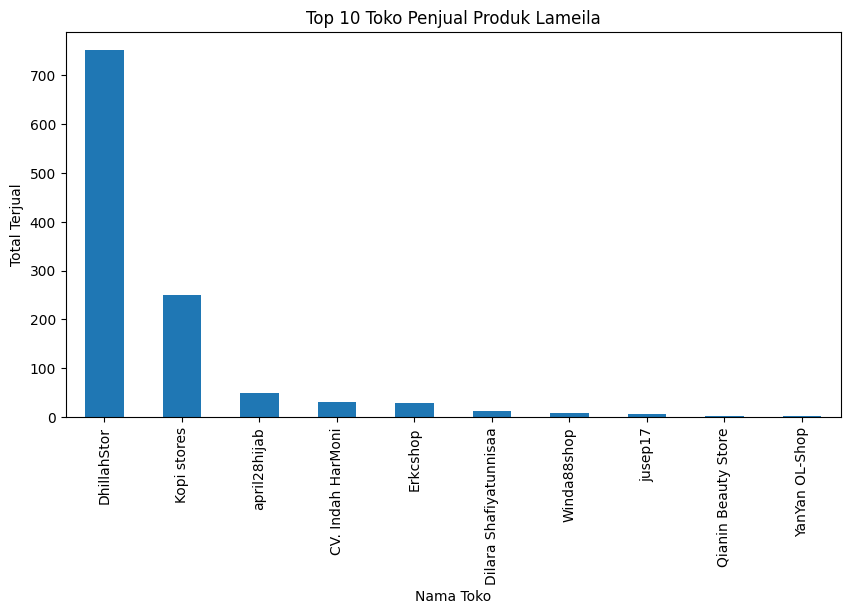

In [ ]:
top_seller1 = outlier_df.groupby('Nama Toko')['Jumlah Terjual'].sum().sort_values(ascending=False).head(10)

top_seller1.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Toko Penjual Produk Lameila")
plt.xlabel("Nama Toko")
plt.ylabel("Total Terjual")
plt.show()

/tmp/ipython-input-2033765527.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outlier_df.groupby(pd.cut(outlier_df['Harga'], bins=10))['Rating'].mean().plot(kind='bar', figsize=(10,5))


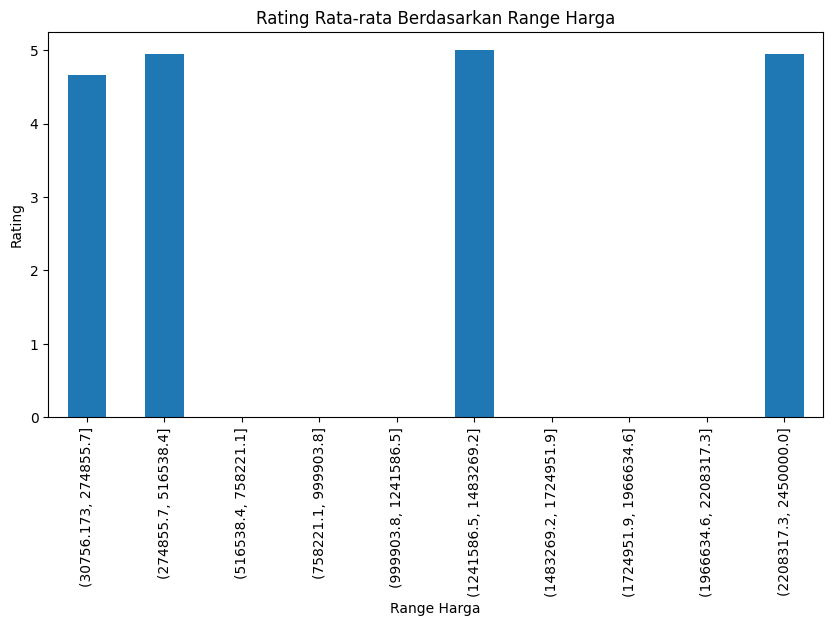

In [ ]:
outlier_df.groupby(pd.cut(outlier_df['Harga'], bins=10))['Rating'].mean().plot(kind='bar', figsize=(10,5))
plt.title("Rating Rata-rata Berdasarkan Range Harga")
plt.xlabel("Range Harga")
plt.ylabel("Rating")
plt.show()

In [ ]:
suspect_sellers = outlier_df[['Nama Toko', 'Nama Produk', 'Harga', 'Jumlah Terjual']]
suspect_sellers.sort_values(by='Harga', ascending=False)

,Nama Toko,Nama Produk,Harga,Jumlah Terjual
127,Y T.k girlz,lameila eyebrow tint my eyebrow pinsil alis 4 ...,2450000,0
34,ainia shop5,Unik LAMEILA concealer Limited,1375000,2
208,YAYINEW,Lameila 1 Set Make up Sultan 30in1 alat makeup...,338520,1
66,YanYan OL-Shop,LAMEILA MAKE-UP SERIES,245000,3
81,Winda88shop,Lameila 15warna kecantikan eyeshadow,200000,9
200,ghaniapermata,Paket Kosmetik Hemat 13 In 1 Lameila Makeup S...,153900,0
114,Berkah Market's,lameila 15 warna palet eyeshadow kecantikan ko...,132500,0
123,Nangset87,Lameila 12 Warna Eyeshadow Plette Palet Eyeshadow,100000,0
97,Nabilah Rania,( GET 6 ) Paket Usaha Lipstik Gold LAMEILA SET...,99730,0
72,CV. Indah HarMoni,Maskara Lameila 772 Eye Mascara Electric Eye R...,99000,30


# clustering

In [ ]:
features = df[['Harga','Jumlah Terjual','Rating']].copy()

standarisasi, wajib untuk kmeans

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

cari cluster optimal

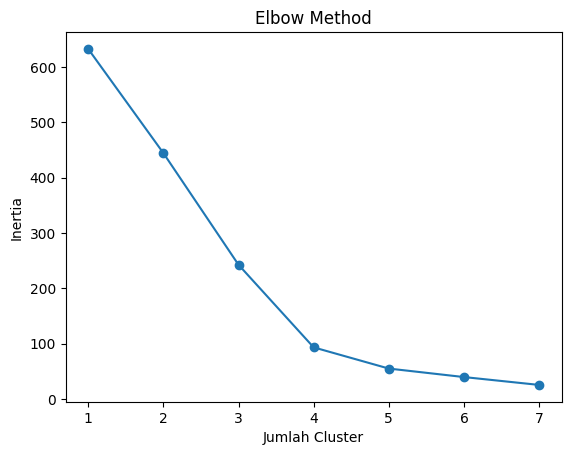

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1,8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

df['Cluster'] = clusters

In [ ]:
df.groupby('Cluster')[['Harga','Jumlah Terjual','Rating']].mean()

,Harga,Jumlah Terjual,Rating
Cluster,,,
0,2.273602e+04,24.670000,4.888000
1,1.912500e+06,1.000000,4.975000
2,6.000000e+03,7000.000000,4.650000
3,2.965671e+04,117.857143,2.528571


interpretasi cluster :

1 = harga rata-rata 1,9jt terjual rata2 1 rating 4,97 (arga ekstrem tinggi, hampir tidak terjual → indikasi penipuan/manipulasi)
2 = harga 6rb terjual 7000 rating 4,65 (harga sangat rendah, penjualan masif → indikasi distribusi agresif produk ilegal)
0 = harga rata rata 22rb jumlah terjual 24 rating 4.88 (harga rendah – penjualan kecil → reseller kecil/penjual oportunistik)
3 = harga 29rb terjual 118 rating 2.52 (harga rendah – rating rendah → potensi barang berkualitas buruk/keluhan konsumen)

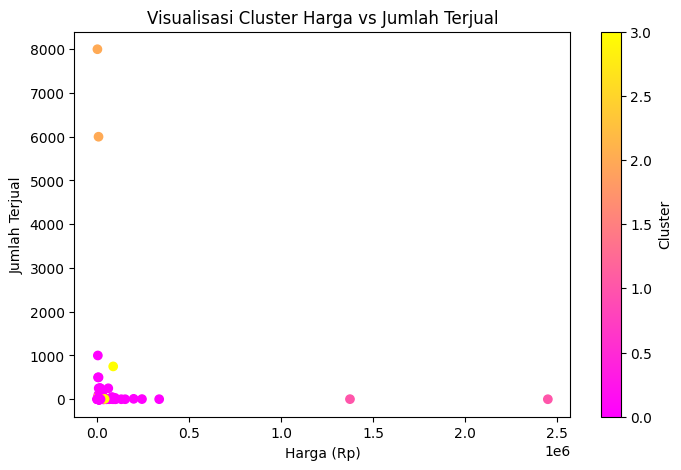

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Harga'], df['Jumlah Terjual'], c=df['Cluster'], cmap='spring')
plt.title("Visualisasi Cluster Harga vs Jumlah Terjual")
plt.xlabel("Harga (Rp)")
plt.ylabel("Jumlah Terjual")
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
suspicious_clusters = [1,2]  # nanti kita isi berdasarkan hasil analisis
suspicious_sellers = df[df['Cluster'].isin(suspicious_clusters)]
suspicious_sellers[['Nama Toko','Nama Produk','Harga','Jumlah Terjual','Rating','Cluster']]

,Nama Toko,Nama Produk,Harga,Jumlah Terjual,Rating,Cluster
18,intenseshop304,SKOT MATA LAMEILA ISI 48PSG A881-S / DOUBLE EY...,3000,8000,4.60,2
34,ainia shop5,Unik LAMEILA concealer Limited,1375000,2,5.00,1
84,Ryenakosmetik97,BB cream lameila bisa untuk penganti bedak,9000,6000,4.70,2
127,Y T.k girlz,lameila eyebrow tint my eyebrow pinsil alis 4 ...,2450000,0,4.95,1


In [ ]:
for c in sorted(df['Cluster'].unique()):
    print(f"\nToko dalam cluster {c}")
    display(df[df['Cluster']==c][['Nama Toko','Nama Produk','Harga','Jumlah Terjual','Rating']].head(10))


Toko dalam cluster 0


,Nama Toko,Nama Produk,Harga,Jumlah Terjual,Rating
0,jusep17,Lameila 4 Color Avocado Eyeshadow Disk Matte S...,7900,30,5.00
1,Sanimeila,Lameila Cleansing Make Up Remover Moisturize M...,18900,4,5.00
2,XO Label,Lameila Moisturizer Lip Mask Blm Mask Pelembab...,12300,12,5.00
3,Pusat Skincare Surabaya,"Lameila Concealer, Concealer",10000,250,4.60
4,belbul21,Lameila~Light And Soft Concelear,8000,12,4.95
5,Sanimeila,LAMEILA BEDAK TABUR SETTING POWDER LOOSE POWDE...,8000,1,5.00
6,KFW Chantique,Lameila pencil alis putar berkepala 2 ada 7 warna,5700,1,5.00
8,Sanimeila,LAMEILA MASCARA 3D KERITING TEBAL MASCARA SLEN...,8800,1,5.00
9,fashion tasbrand,LAMEILA 1001 BB CREAM KOREAN ORIGINAL,23100,1,4.95
10,Sanimeila,LAMEILA CONCEALER CONTOUR HIGHLIGHTER EYESHADO...,5500,1,5.00



Toko dalam cluster 1


,Nama Toko,Nama Produk,Harga,Jumlah Terjual,Rating
34,ainia shop5,Unik LAMEILA concealer Limited,1375000,2,5.00
127,Y T.k girlz,lameila eyebrow tint my eyebrow pinsil alis 4 ...,2450000,0,4.95



Toko dalam cluster 2


,Nama Toko,Nama Produk,Harga,Jumlah Terjual,Rating
18,intenseshop304,SKOT MATA LAMEILA ISI 48PSG A881-S / DOUBLE EY...,3000,8000,4.6
84,Ryenakosmetik97,BB cream lameila bisa untuk penganti bedak,9000,6000,4.7



Toko dalam cluster 3


,Nama Toko,Nama Produk,Harga,Jumlah Terjual,Rating
7,mytmey21,LAMEILA Gold Edition MATTE LIPSTIK,18998,3,3.0
74,Glowris Store,LAMEILA Eyeshadow Palette 10 Warna 100% Original,14999,3,1.0
76,DhillahStor,Lameila Maskara Langit Berbintang Natural Anti...,88700,750,3.0
147,Alpha Beauty Box,Lameila Compact Powder 2 Susun Elegant High Qu...,21500,1,3.0
155,hellosummermakeupmall,SUMMER POWDER SHIMMER HIGHLIGHTER GLITTER Face...,12900,1,3.0
168,Pusat Skincare Surabaya,lameila velvet glaze,8500,60,3.7
206,jusep17,Lameila Bedak Tabur Loose Powder Oil Control w...,42000,7,1.0


In [ ]:
high_risk_clusters = [1,2]
high_risk_df = df[df['Cluster'].isin(high_risk_clusters)]
high_risk_df[['Nama Toko','Nama Produk','Harga','Jumlah Terjual','Rating','Cluster']]

,Nama Toko,Nama Produk,Harga,Jumlah Terjual,Rating,Cluster
18,intenseshop304,SKOT MATA LAMEILA ISI 48PSG A881-S / DOUBLE EY...,3000,8000,4.60,2
34,ainia shop5,Unik LAMEILA concealer Limited,1375000,2,5.00,1
84,Ryenakosmetik97,BB cream lameila bisa untuk penganti bedak,9000,6000,4.70,2
127,Y T.k girlz,lameila eyebrow tint my eyebrow pinsil alis 4 ...,2450000,0,4.95,1


<Figure size 1200x600 with 0 Axes>

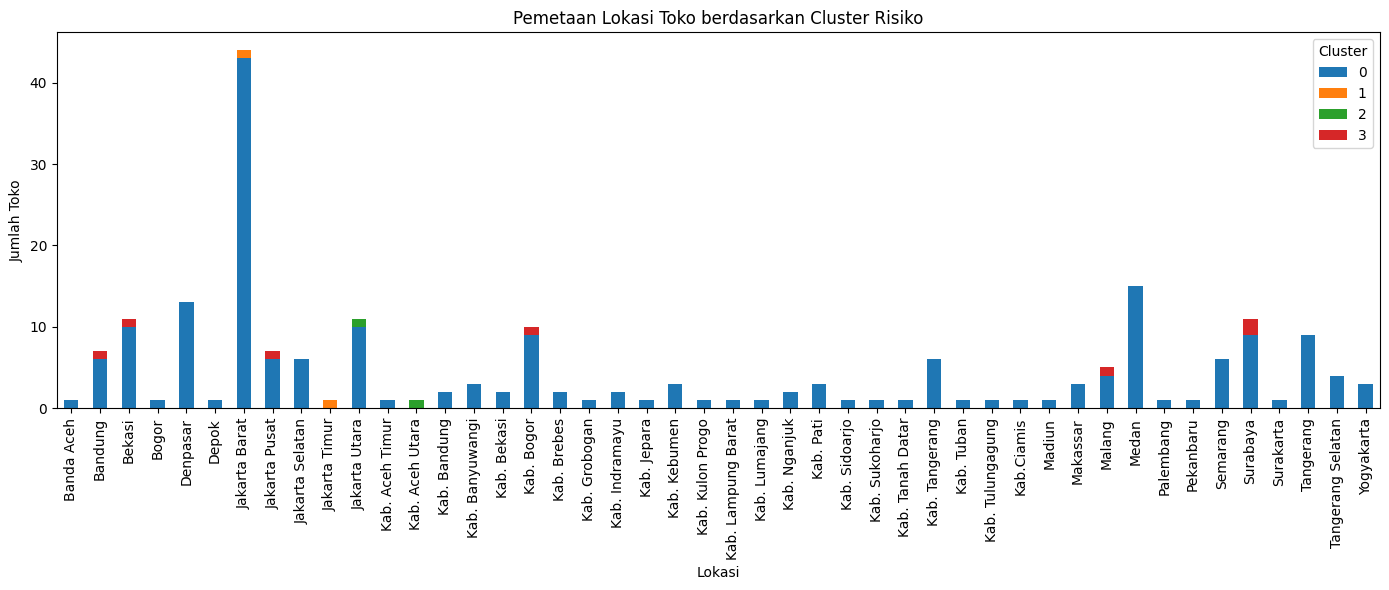

In [ ]:
import matplotlib.pyplot as plt

# hitung jumlah toko per lokasi per cluster
lokasi_cluster = df.groupby(['Kota','Cluster'])['Nama Toko'].count().reset_index()
lokasi_cluster.columns = ['Kota','Cluster','jumlah_toko']

# pivot agar lokasi sebagai bar dan cluster jadi kelompok
pivot_table = lokasi_cluster.pivot(index='Kota', columns='Cluster', values='jumlah_toko').fillna(0)

plt.figure(figsize=(12,6))
pivot_table.plot(kind='bar', stacked=True, figsize=(14,6))

plt.title("Pemetaan Lokasi Toko berdasarkan Cluster Risiko")
plt.xlabel("Lokasi")
plt.ylabel("Jumlah Toko")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# Kesimpulan Cluster

Hasil analisis clustering terhadap pola penjualan produk kosmetik tanpa izin edar merek Lameila pada platform marketplace menunjukkan adanya segmentasi risiko kriminalitas digital. Temuan ini perlu dikaitkan dengan ketentuan regulasi yang berlaku di Indonesia. Berdasarkan Peraturan Pemerintah Nomor 36 Tahun 2017 tentang Perdagangan Melalui Sistem Elektronik, pelaku usaha wajib memastikan legalitas produk yang diperdagangkan secara daring, termasuk pemenuhan persyaratan perizinan. Pada sektor kosmetika, setiap produk wajib memiliki izin edar berupa Notifikasi Kosmetika dari Badan Pengawas Obat dan Makanan (BPOM) sebagai bukti bahwa produk tersebut aman dan memenuhi standar mutu. Oleh karena itu, cluster dengan karakteristik harga sangat rendah dan jumlah penjualan sangat tinggi mengindikasikan potensi distribusi ilegal dalam skala besar yang melanggar ketentuan izin edar. Sementara itu, cluster dengan harga sangat tinggi namun minim penjualan dapat mencerminkan potensi manipulasi harga atau penipuan pada transaksi elektronik. Selain itu, cluster dengan rating rendah mencerminkan kemungkinan risiko keamanan produk, karena ulasan negatif sering kali berkaitan dengan ketidaksesuaian mutu atau efek samping berbahaya. Dengan demikian, hasil clustering tidak hanya memberikan insight pola penjualan di marketplace, tetapi juga menjadi dasar bagi prioritas pengawasan dan penindakan sesuai ketentuan regulasi perdagangan elektronik dan keamanan kosmetika.

# Rekomendasi Tindak Lanjut BPOM

Berdasarkan hasil analisis clustering dan visualisasi pemetaan distribusi penjualan produk kosmetik tanpa izin edar merek Lameila di marketplace Tokopedia, BBPOM disarankan untuk menetapkan prioritas pengawasan pada lokasi-lokasi dengan konsentrasi penjual tertinggi dan cluster berisiko tinggi. Tindak lanjut dapat dilakukan melalui pemeriksaan toko online yang teridentifikasi menjual produk ilegal, termasuk verifikasi legalitas izin edar dan klarifikasi rantai distribusi produk. Selain upaya penindakan, BBPOM juga perlu memperkuat kegiatan edukasi kepada konsumen agar lebih kritis dalam memilih produk kosmetik, termasuk cara memeriksa izin edar dan mengenali potensi bahaya produk ilegal. Pendekatan pengawasan berbasis data ini diharapkan dapat meningkatkan efektivitas mitigasi risiko terhadap peredaran kosmetik ilegal di pasar digital.

# anomaly detection harga

metode : iqr (interquartile range ; krn data markerplace cenderung skewed)

In [ ]:
Q1 = df['Harga'].quantile(0.25)
Q3 = df['Harga'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -5575.0
Upper bound: 32865.0


harga produk tdk mungkin negatif, nilai negatif krn rumus matematis q1 - 1.5xIQR = tidak ada harga anomali dibawah batas bawah (smua nilai diatas 0)

upper = 32.865

harga diatas Rp 32.865 dianggap anomali, artiny harga > 32rb tdk wjar bagi produk lameila  krn dia ini produk murah tanpa izin edar

In [ ]:
anomali_harga = df[(df['Harga'] < lower_bound) | (df['Harga'] > upper_bound)]
anomali_harga.head()

,Link Produk,Deskripsi,Nama Produk,Harga,Rating,Jumlah Terjual,Nama Toko,Kota,Cluster
13,https://www.tokopedia.com/april28hijab/paket-k...,Paket Kosmetik Super Lengkap 19 In 1 Lameila T...,Paket Kosmetik Super Lengkap 19 In 1 Lameila T...,82600,4.8,50,april28hijab,Surabaya,0
34,https://www.tokopedia.com/ainia/unik-lameila-c...,SHADE RANDOM ETALASE HADIAH JANGAN DIBELI SKU ...,Unik LAMEILA concealer Limited,1375000,5.0,2,ainia shop5,Jakarta Barat,1
35,https://www.tokopedia.com/karomajaya-1/facial-...,welcome to karoma jaya siakan di order kak Spe...,FACIAL CLEANSING PAD LAMEILA / SIKAT FACIAL MUKA,48500,4.6,2,karomajaya store,Jakarta Barat,0
41,https://www.tokopedia.com/bening-store16/lamei...,Lameila Quicksand Makeup Spray - Botol 150ml.\...,LAMEILA MAKEUP SETTING SPRAY UNTUK MAKEUP TAHA...,33900,4.3,1,Bening Store16,Jakarta Selatan,0
59,https://www.tokopedia.com/dilarashafiyatunnisa...,Lameila Paket (A)10 item Foundation Eyeshadow ...,Lameila paket A kosmetik 10pcs_ Berkualitas,78000,5.0,12,Dilara Shafiyatunnisaa,Jakarta Barat,0


In [ ]:
anomali_harga[['Nama Toko','Nama Produk','Harga','Jumlah Terjual','Rating']]

,Nama Toko,Nama Produk,Harga,Jumlah Terjual,Rating
13,april28hijab,Paket Kosmetik Super Lengkap 19 In 1 Lameila T...,82600,50,4.80
34,ainia shop5,Unik LAMEILA concealer Limited,1375000,2,5.00
35,karomajaya store,FACIAL CLEANSING PAD LAMEILA / SIKAT FACIAL MUKA,48500,2,4.60
41,Bening Store16,LAMEILA MAKEUP SETTING SPRAY UNTUK MAKEUP TAHA...,33900,1,4.30
59,Dilara Shafiyatunnisaa,Lameila paket A kosmetik 10pcs_ Berkualitas,78000,12,5.00
61,HAMAD SAID HANAFI HRTYHBDEFSVS,LML LAMEIL SVML 5137 Air Cushion BB Cream Conc...,66000,1,5.00
66,YanYan OL-Shop,LAMEILA MAKE-UP SERIES,245000,3,5.00
67,DhillahStor,Lameila Pen Eyeliner Cair Tahan Lama & Anti Air,89000,1,5.00
72,CV. Indah HarMoni,Maskara Lameila 772 Eye Mascara Electric Eye R...,99000,30,4.90
76,DhillahStor,Lameila Maskara Langit Berbintang Natural Anti...,88700,750,3.00


In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.03, random_state=42)
df['anomaly_price'] = iso.fit_predict(df[['Harga','Jumlah Terjual']])
anomali_iforest = df[df['anomaly_price'] == -1]
anomali_iforest[['Nama Toko','Nama Produk','Harga','Jumlah Terjual']]

,Nama Toko,Nama Produk,Harga,Jumlah Terjual
18,intenseshop304,SKOT MATA LAMEILA ISI 48PSG A881-S / DOUBLE EY...,3000,8000
34,ainia shop5,Unik LAMEILA concealer Limited,1375000,2
76,DhillahStor,Lameila Maskara Langit Berbintang Natural Anti...,88700,750
84,Ryenakosmetik97,BB cream lameila bisa untuk penganti bedak,9000,6000
127,Y T.k girlz,lameila eyebrow tint my eyebrow pinsil alis 4 ...,2450000,0
203,MJ STAR Official,LAMEILA - Beauty Blender Labu With Holder High...,5335,1000
208,YAYINEW,Lameila 1 Set Make up Sultan 30in1 alat makeup...,338520,1


In [ ]:
# definisi cluster risiko tinggi berdasarkan hasil clustering
high_risk_clusters = [1, 2]  # manipulasi harga & distribusi massal
medium_risk_clusters = [3]   # rating rendah

def classify_risk(row):
    # kalau anomaly & cluster berisiko tinggi → high risk
    if row['anomaly_price'] == -1 and row['Cluster'] in high_risk_clusters:
        return "HIGH RISK"
    # kalau anomaly ATAU cluster berisiko → medium
    elif row['anomaly_price'] == -1 or row['Cluster'] in medium_risk_clusters:
        return "MEDIUM RISK"
    # sisanya low
    else:
        return "LOW RISK"

df['risk_label'] = df.apply(classify_risk, axis=1)
df[['Nama Toko','Nama Produk','Harga','Jumlah Terjual','Cluster','anomaly_price','risk_label']].head()

,Nama Toko,Nama Produk,Harga,Jumlah Terjual,Cluster,anomaly_price,risk_label
0,jusep17,Lameila 4 Color Avocado Eyeshadow Disk Matte S...,7900,30,0,1,LOW RISK
1,Sanimeila,Lameila Cleansing Make Up Remover Moisturize M...,18900,4,0,1,LOW RISK
2,XO Label,Lameila Moisturizer Lip Mask Blm Mask Pelembab...,12300,12,0,1,LOW RISK
3,Pusat Skincare Surabaya,"Lameila Concealer, Concealer",10000,250,0,1,LOW RISK
4,belbul21,Lameila~Light And Soft Concelear,8000,12,0,1,LOW RISK


In [ ]:
df

,Link Produk,Deskripsi,Nama Produk,Harga,Rating,Jumlah Terjual,Nama Toko,Kota,Cluster,anomaly_price,risk_label
0,https://www.tokopedia.com/mupdaily2/lameila-4-...,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,Lameila 4 Color Avocado Eyeshadow Disk Matte S...,7900,5.00,30,jusep17,Bandung,0,1,LOW RISK
1,https://www.tokopedia.com/sanimeila/lameila-cl...,LAMEILA Cleansing Makeup Remover Moisturize . ...,Lameila Cleansing Make Up Remover Moisturize M...,18900,5.00,4,Sanimeila,Jakarta Barat,0,1,LOW RISK
2,https://www.tokopedia.com/xolabel/lameila-mois...,LAMEILA Cleansing Makeup Remover Moisturize . ...,Lameila Moisturizer Lip Mask Blm Mask Pelembab...,12300,5.00,12,XO Label,Kab. Tangerang,0,1,LOW RISK
3,https://www.tokopedia.com/pusatskincaresurabay...,KEUNGGULAN : * Mudah di aplikasikan dengan apl...,"Lameila Concealer, Concealer",10000,4.60,250,Pusat Skincare Surabaya,Surabaya,0,1,LOW RISK
4,https://www.tokopedia.com/belbul21/lameila-lig...,manfaat : ~ memudahkan juga menerapkan dala me...,Lameila~Light And Soft Concelear,8000,4.95,12,belbul21,Denpasar,0,1,LOW RISK
...,...,...,...,...,...,...,...,...,...,...,...
206,https://www.tokopedia.com/mupdaily2/lameila-be...,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,Lameila Bedak Tabur Loose Powder Oil Control w...,42000,1.00,7,jusep17,Bandung,3,1,MEDIUM RISK
207,https://www.tokopedia.com/glowris/cod-lameila-...,LAMEILA FACE STICK CONCEALER 2 IN 1\n\nLameila...,[ COD ] Lameila Face Stick 2in1 Concealer Stic...,10185,4.70,13,Glowris Store,Kab. Bogor,0,1,LOW RISK
208,https://www.tokopedia.com/neli-merdihilac/lame...,SIAP LANGSUNG KIRIM BISA COD\nBEAUTY MAKE UP S...,Lameila 1 Set Make up Sultan 30in1 alat makeup...,338520,4.95,1,YAYINEW,Depok,0,-1,MEDIUM RISK
209,https://www.tokopedia.com/herliza-julvita-idw8...,Keunggulan :BB Cream ini dengan tekstur ringan...,LML LAMEIL SVML 5137 Air Cushion BB Cream Conc...,19998,4.95,1,HERLIZA JULVITA-iDw8aHEYpI,Jakarta Pusat,0,1,LOW RISK


In [ ]:
anomaly_location = (
    df[df['risk_label'] != 'LOW RISK']
    .groupby(['Kota','risk_label'])['Nama Toko']
    .count()
    .reset_index())

anomaly_location

,Kota,risk_label,Nama Toko
0,Bandung,MEDIUM RISK,1
1,Bekasi,MEDIUM RISK,2
2,Depok,MEDIUM RISK,1
3,Jakarta Barat,HIGH RISK,1
4,Jakarta Pusat,MEDIUM RISK,1
5,Jakarta Timur,HIGH RISK,1
6,Jakarta Utara,HIGH RISK,1
7,Kab. Aceh Utara,HIGH RISK,1
8,Kab. Bogor,MEDIUM RISK,1
9,Malang,MEDIUM RISK,1


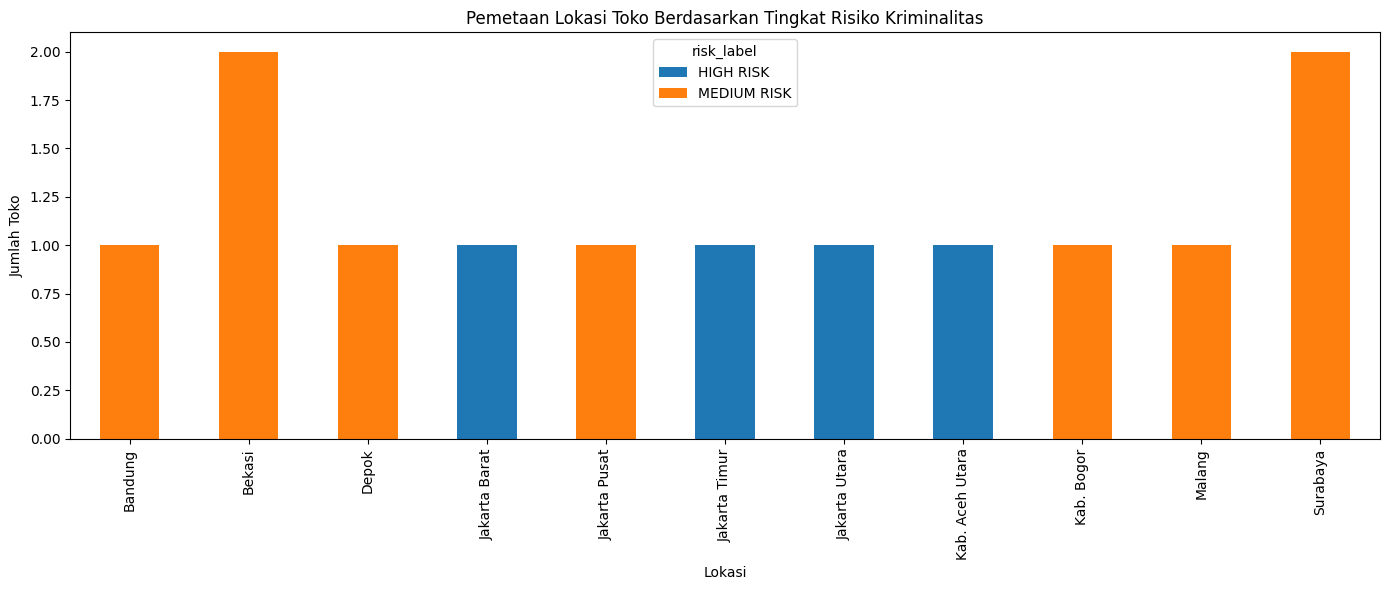

In [ ]:
pivot_anom = anomaly_location.pivot(index='Kota', columns='risk_label', values='Nama Toko').fillna(0)

pivot_anom.plot(kind='bar', stacked=True, figsize=(14,6))
plt.title("Pemetaan Lokasi Toko Berdasarkan Tingkat Risiko Kriminalitas")
plt.xlabel("Lokasi")
plt.ylabel("Jumlah Toko")
plt.tight_layout()
plt.show()

# Text Mining Deskripsi Produk

buat lihat keyword seperti apa yang sering digunakan penjual dalam mengisi deskripsi

In [ ]:
df.head()

,Link Produk,Deskripsi,Nama Produk,Harga,Rating,Jumlah Terjual,Nama Toko,Kota,Cluster,anomaly_price,risk_label
0,https://www.tokopedia.com/mupdaily2/lameila-4-...,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,Lameila 4 Color Avocado Eyeshadow Disk Matte S...,7900,5.00,30,jusep17,Bandung,0,1,LOW RISK
1,https://www.tokopedia.com/sanimeila/lameila-cl...,LAMEILA Cleansing Makeup Remover Moisturize . ...,Lameila Cleansing Make Up Remover Moisturize M...,18900,5.00,4,Sanimeila,Jakarta Barat,0,1,LOW RISK
2,https://www.tokopedia.com/xolabel/lameila-mois...,LAMEILA Cleansing Makeup Remover Moisturize . ...,Lameila Moisturizer Lip Mask Blm Mask Pelembab...,12300,5.00,12,XO Label,Kab. Tangerang,0,1,LOW RISK
3,https://www.tokopedia.com/pusatskincaresurabay...,KEUNGGULAN : * Mudah di aplikasikan dengan apl...,"Lameila Concealer, Concealer",10000,4.60,250,Pusat Skincare Surabaya,Surabaya,0,1,LOW RISK
4,https://www.tokopedia.com/belbul21/lameila-lig...,manfaat : ~ memudahkan juga menerapkan dala me...,Lameila~Light And Soft Concelear,8000,4.95,12,belbul21,Denpasar,0,1,LOW RISK


In [ ]:
pre_text = df['Deskripsi']
pre_text

,Deskripsi
0,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...
1,LAMEILA Cleansing Makeup Remover Moisturize . ...
2,LAMEILA Cleansing Makeup Remover Moisturize . ...
3,KEUNGGULAN : * Mudah di aplikasikan dengan apl...
4,manfaat : ~ memudahkan juga menerapkan dala me...
...,...
206,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...
207,LAMEILA FACE STICK CONCEALER 2 IN 1\n\nLameila...
208,SIAP LANGSUNG KIRIM BISA COD\nBEAUTY MAKE UP S...
209,Keunggulan :BB Cream ini dengan tekstur ringan...


In [ ]:
import re

# Proses pembersihan teks
dataclean = []
for line in pre_text:
    line = re.sub(r"http\S+", " ", line)            # Menghapus link
    line = re.sub(r"@\S+", " ", line)               # Menghapus username
    line = re.sub(r"#\S+", " ", line)               # Menghapus hashtag
    line = re.sub(r"\d", " ", line)                 # Menghapus angka
    line = re.sub(r"<.*?>", " ", line)              # Menghapus emotikon/HTML tag
    line = re.sub(r"\n", " ", line)                 # Menghapus baris baru
    line = re.sub(r",", " ", line)                  # Menghapus koma
    line = re.sub(r"[^\w\s]", " ", line)            # Menghapus tanda baca
    line = re.sub(r"\s+", " ", line).strip()        # Menghapus spasi berlebih
    dataclean.append(line)

In [ ]:
# Membuat DataFrame perbandingan
datahapus = pd.DataFrame({
    'Sebelum Cleaning': pre_text,
    'Sesudah Cleaning': dataclean
})

# Menampilkan DataFrame
datahapus.head()

,Sebelum Cleaning,Sesudah Cleaning
0,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,KLIK IKUTI FOLLOW Toko Mupdaily akan mendapatk...
1,LAMEILA Cleansing Makeup Remover Moisturize . ...,LAMEILA Cleansing Makeup Remover Moisturize Ke...
2,LAMEILA Cleansing Makeup Remover Moisturize . ...,LAMEILA Cleansing Makeup Remover Moisturize Ke...
3,KEUNGGULAN : * Mudah di aplikasikan dengan apl...,KEUNGGULAN Mudah di aplikasikan dengan aplikat...
4,manfaat : ~ memudahkan juga menerapkan dala me...,manfaat memudahkan juga menerapkan dala memaka...


In [ ]:
kata = {
    "g ": "tidak ",
    "ga ": "tidak ",
    "gak ": "tidak ",
    "nggak ": "tidak ",
    "ngga ": "tidak ",
    "enggak ": "tidak ",
    "engga ": "tidak ",
    "gk ": "tidak ",
    "gx ": "tidak ",
    "tdk ": "tidak ",
    "tak ": "tidak ",
    "kagak ": "tidak ",
    "ora ": "tidak ",
    "ndak ": "tidak ",
    "gada ": "tidak ",
    "jgn ": "jangan ",
    "jngn ": "jangan ",
    "gw ": "saya ",
    "gue ": "saya ",
    "gua ": "saya ",
    "aq ": "saya ",
    "aku ": "saya ",
    "sy ": "saya ",
    "sya ": "saya ",
    "lu ": "kamu ",
    "loe ": "kamu ",
    "lo ": "kamu ",
    "elu ": "kamu ",
    "km ": "kamu ",
    "kmu ": "kamu ",
    "kak ": "kakak ",
    "kaka ": "kakak ",
    "sis ": "kakak ",
    "bro ": "kakak ",
    "gan ": "kakak ",
    "min ": "admin ",
    "guys ": "teman ",
    "guysss ": "teman ",
    "guysnya ": "teman ",
    "guysssnya ": "teman ",
    "yg ": "yang ",
    "yg. ": "yang ",
    "yng ": "yang ",
    "dgn ": "dengan ",
    "dg ": "dengan ",
    "dngn ": "dengan ",
    "dr ": "dari ",
    "dri ": "dari ",
    "utk ": "untuk ",
    "bwt ": "untuk ",
    "buat ": "untuk ",
    "buatnya ": "untuk ",
    "u/ ": "untuk ",
    "u ": "untuk ",
    "krn ": "karena ",
    "karna ": "karena ",
    "krna ": "karena ",
    "soalnya ": "karena ",
    "klo ": "kalau ",
    "kl ": "kalau ",
    "kalo ": "kalau ",
    "kalok ": "kalau ",
    "tp ": "tapi ",
    "tpi ": "tapi ",
    "tapii ": "tapi ",
    "aja ": "saja ",
    "aj ": "saja ",
    "doang ": "saja ",
    "jg ": "juga ",
    "jga ": "juga ",
    "juga ": "juga ",
    "trs ": "terus ",
    "trus ": "terus ",
    "trusss ": "terus ",
    "teross ": "terus ",
    "sm ": "sama ",
    "ama ": "sama ",
    "pd ": "pada ",
    "dll ": "dan lain lain ",
    "dsb ": "dan sebagainya ",
    "dst ": "dan seterusnya ",
    "dkk ": "dan kawan kawan ",
    "sbg ": "sebagai ",
    "bgt ": "banget ",
    "bgtt ": "banget ",
    "bngt ": "banget ",
    "bangettt ": "banget ",
    "bangett ": "banget ",
    "bener ": "benar ",
    "bner ": "benar ",
    "td ": "tadi ",
    "kyk ": "seperti ",
    "kayak ": "seperti ",
    "spt ": "seperti ",
    "sperti ": "seperti ",
    "lg ": "lagi ",
    "lgi ": "lagi ",
    "lagi2 ": "lagi lagi ",
    "mksh ": "terima kasih ",
    "makasih ": "terima kasih ",
    "makasi ": "terima kasih ",
    "thx ": "terima kasih ",
    "pake ": "pakai ",
    "dipake ": "dipakai ",
    "kepake ": "terpakai ",
    "bkin ": "membuat ",
    "dpt ": "dapat ",
    "dapet ": "dapat ",
    "cek ": "periksa ",
    "check ": "periksa ",
    "ngecek ": "memeriksa ",
    "skin care ": "skincare ",
    "skin-care ": "skincare ",
    "make-up ": "makeup ",
    "make up ": "makeup ",
    "abal ": "palsu ",
    "ijin ": "izin ",
    "ijin edar ": "izin edar ",
    "nomer ": "nomor ",
    "oknum2 ": "oknum ",
    "produk2 ": "produk ",
    "orang2 ": "orang "
}

In [ ]:
def replace(text, dic):
    for typo, correct in dic.items():
        text = re.sub(r'\b{}\b'.format(re.escape(typo)), correct, text)
    return text

In [ ]:
dic = OrderedDict(kata)

In [ ]:
datachange = []
for line in dataclean:
    result = replace(line, dic)
    datachange.append(result)

In [ ]:
df_change = pd.DataFrame({
    'Sebelum Normalisasi': dataclean,
    'Sesudah Normalisasi': datachange
})

# Tampilkan DataFrame
df_change.head(40)

,Sebelum Normalisasi,Sesudah Normalisasi
0,KLIK IKUTI FOLLOW Toko Mupdaily akan mendapatk...,KLIK IKUTI FOLLOW Toko Mupdaily akan mendapatk...
1,LAMEILA Cleansing Makeup Remover Moisturize Ke...,LAMEILA Cleansing Makeup Remover Moisturize Ke...
2,LAMEILA Cleansing Makeup Remover Moisturize Ke...,LAMEILA Cleansing Makeup Remover Moisturize Ke...
3,KEUNGGULAN Mudah di aplikasikan dengan aplikat...,KEUNGGULAN Mudah di aplikasikan dengan aplikat...
4,manfaat memudahkan juga menerapkan dala memaka...,manfaat memudahkan juga menerapkan dala memaka...
5,LAMEILA LOOSE POWDER BEDAK TABUR MERK LAMEILA ...,LAMEILA LOOSE POWDER BEDAK TABUR MERK LAMEILA ...
6,Pensil Alis Segitiga Dapat Digunakan Tanpa Rot...,Pensil Alis Segitiga Dapat Digunakan Tanpa Rot...
7,Merek produk LAMEILA Warna produk warna Jenis ...,Merek produk LAMEILA Warna produk warna Jenis ...
8,Lameila Mascara Mascara Waterproof Black Green...,Lameila Mascara Mascara Waterproof Black Green...
9,BACA DESKRIPSI TERLEBIH DAHULU SEBELUM ORDER S...,BACA DESKRIPSI TERLEBIH DAHULU SEBELUM ORDER S...


In [ ]:
data_lower=[]
for line in datachange:
    a = line.lower()
    data_lower.append(a)

In [ ]:
df_lower = pd.DataFrame({
    'Sebelum Lowercase': datachange,
    'Sesudah Lowercase': data_lower})
df_lower.head()

,Sebelum Lowercase,Sesudah Lowercase
0,KLIK IKUTI FOLLOW Toko Mupdaily akan mendapatk...,klik ikuti follow toko mupdaily akan mendapatk...
1,LAMEILA Cleansing Makeup Remover Moisturize Ke...,lameila cleansing makeup remover moisturize ke...
2,LAMEILA Cleansing Makeup Remover Moisturize Ke...,lameila cleansing makeup remover moisturize ke...
3,KEUNGGULAN Mudah di aplikasikan dengan aplikat...,keunggulan mudah di aplikasikan dengan aplikat...
4,manfaat memudahkan juga menerapkan dala memaka...,manfaat memudahkan juga menerapkan dala memaka...


In [ ]:
#Stemming :
factory=StemmerFactory()
stemmer=factory.create_stemmer()
datastemmed=map(lambda x: stemmer.stem(x), datachange)
datastemmed=list(datastemmed)

In [ ]:
df_stem = pd.DataFrame({
    'Sebelum Stemming': data_lower,
    'Setelah Stemming': datastemmed,
})

df_stem.head()

,Sebelum Stemming,Setelah Stemming
0,klik ikuti follow toko mupdaily akan mendapatk...,klik ikut follow toko mupdaily akan dapat free...
1,lameila cleansing makeup remover moisturize ke...,lameila cleansing makeup remover moisturize ke...
2,lameila cleansing makeup remover moisturize ke...,lameila cleansing makeup remover moisturize ke...
3,keunggulan mudah di aplikasikan dengan aplikat...,unggul mudah di aplikasi dengan aplikator warn...
4,manfaat memudahkan juga menerapkan dala memaka...,manfaat mudah juga terap dala pakai dan hapus ...


In [ ]:
with open("/content/stopword kriminal.txt", "r", encoding="latin-1") as f:
    stopwords = f.read().splitlines()
databersih = [
    " ".join([word for word in word_tokenize(kalimat) if word.lower() not in stopwords])
    for kalimat in datastemmed
]

In [ ]:
df_stopwords = pd.DataFrame({
    'Sebelum Stopwords Removal': datastemmed,
    'Sesudah Stopwords Removal': databersih
})

# Tampilkan hasil perbandingan
df_stopwords.head()

,Sebelum Stopwords Removal,Sesudah Stopwords Removal
0,klik ikut follow toko mupdaily akan dapat free...,mupdaily packing bubble wrap lapis dus fragile...
1,lameila cleansing makeup remover moisturize ke...,cleansing remover moisturize ketika terlalu le...
2,lameila cleansing makeup remover moisturize ke...,cleansing remover moisturize ketika terlalu le...
3,unggul mudah di aplikasi dengan aplikator warn...,unggul mudah aplikasi aplikator natural kering...
4,manfaat mudah juga terap dala pakai dan hapus ...,manfaat mudah terap hapus kerut noda wajah cer...


In [ ]:
satudata=[]
datakriminal=[]
kriminal=[]

In [ ]:
for line in databersih:
    wo = word_tokenize(line)
    wo = [word for word in wo if not word in stopwords and not word[0].isdigit()]
    datakriminal.append(wo)
    kriminal.append(" ".join(wo))

In [ ]:
print(datakriminal)

[['mupdaily', 'packing', 'bubble', 'wrap', 'lapis', 'dus', 'fragile', 'lakban', 'eyeshadow', 'disk', 'matte', 'shimmer', 'eyeshadow', 'palette', 'lm', 'putih', 'pink', 'kuning', 'merah', 'abu', 'abu', 'coklat', 'biru', 'spesifikasi', 'spesifikasi', 'normal', 'tahun', 'jumlah', 'empat', 'kulit', 'laku', 'netral', 'kategori', 'eye', 'shadow', 'palet', 'eyeshadow', 'kandung', 'bedak', 'eye', 'shadow', 'beda', 'mudah', 'bagai', 'gaya', 'rias', 'eye', 'shadow', 'beda', 'bedak', 'eye', 'shadow', 'halus', 'mudah', 'aplikasi', 'milik', 'baik', 'campur', 'baik', 'kulit', 'eye', 'shadow', 'eye', 'shadow', 'tiga', 'dimensi', 'mata', 'hidup', 'besar', 'formula', 'anti', 'tambah', 'bedak', 'rias', 'mudah', 'luntur', 'mudah', 'panjang', 'sedia', 'bagai', 'macam', 'pilih', 'penuh', 'agam', 'butuh', 'pilih', 'favorit'], ['cleansing', 'remover', 'moisturize', 'ketika', 'terlalu', 'lelah', 'antuk', 'cuci', 'muka', 'telah', 'panjang', 'remover', 'teman', 'baik', 'cleansing', 'make', 'up', 'remover', 'lem

In [ ]:
for l in datakriminal:
    satudata+= l

In [ ]:
final={v: satudata.count(v) for v in set(satudata)}

In [ ]:
import csv
with open('final1_stemming.csv', 'w', newline='', encoding='utf-8') as csv_file:
    writer = csv.writer(csv_file)
    for key, value in final.items():
        writer.writerow([key, value])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_vect = TfidfVectorizer(min_df=34, use_idf=True)
X_tfidf = tfidf_vect.fit_transform(kriminal)
print(X_tfidf.toarray())
print(X_tfidf.shape)

tf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vect.get_feature_names_out())
print(tf)
print(tf.shape)

[[0.         0.         0.13251589 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.22225966 0.        ]
 [0.         0.         0.         ... 0.         0.22225966 0.        ]
 ...
 [0.34654262 0.         0.         ... 0.         0.1382027  0.        ]
 [0.         0.13878989 0.         ... 0.         0.63711558 0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
(211, 39)
          ada    alami  aplikasi     bagai  bahan      baik     bedak  berat  \
0    0.000000  0.00000  0.132516  0.279077    0.0  0.298183  0.422411    0.0   
1    0.000000  0.00000  0.000000  0.000000    0.0  0.146185  0.000000    0.0   
2    0.000000  0.00000  0.000000  0.000000    0.0  0.146185  0.000000    0.0   
3    0.000000  0.00000  0.159422  0.335741    0.0  0.179363  0.000000    0.0   
4    0.000000  0.00000  0.330987  0.000000    0.0  0.000000  0.000000    0.0   
..        ...      ...       ...       ...    ...       ...       

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

kata = pd.DataFrame.from_dict(final,orient='index')
hasilsort = kata.sort_values(by=[0], ascending=False)
print(hasilsort)
pd.DataFrame(hasilsort).to_csv('hasilsort.csv', index=True)

          0
kulit   318
tahan   273
mata    206
mudah   161
wajah   141
...     ...
pegang    2
yaa       2
buaya     2
off       2
dye       2

[1125 rows x 1 columns]


In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [ ]:
word_freq_dict = hasilsort[0].to_dict()

#mpl.rcParams['figure.figsize']=(8.0,6.0) #(6.0,4.0)
mpl.rcParams['font.size']=12 #10
mpl.rcParams['savefig.dpi']=100 #72
mpl.rcParams['figure.subplot.bottom']=.1

Wordcloud = WordCloud(
    collocations=False,
    background_color='white',
    max_words=10000,
    max_font_size=200,
    min_font_size=5,
    scale=2,
    width=800,
    height=600,
    random_state=43
).generate_from_frequencies(word_freq_dict)

In [ ]:
print(Wordcloud)

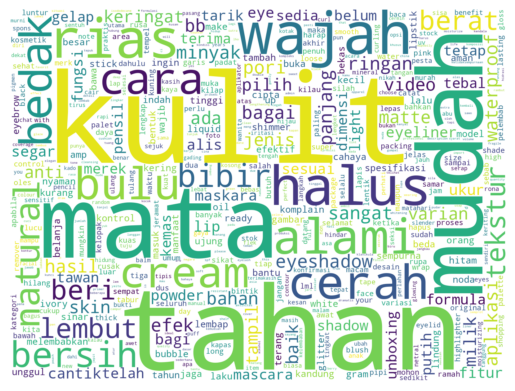

In [ ]:
fig = plt.figure(1)
plt.imshow(Wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
fig.savefig('datanet5.png', dpi=300)

# association rule mining


In [ ]:
df['Token'] = datakriminal
df

,Link Produk,Deskripsi,Nama Produk,Harga,Rating,Jumlah Terjual,Nama Toko,Kota,Cluster,anomaly_price,risk_label,Token
0,https://www.tokopedia.com/mupdaily2/lameila-4-...,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,Lameila 4 Color Avocado Eyeshadow Disk Matte S...,7900,5.00,30,jusep17,Bandung,0,1,LOW RISK,"[mupdaily, packing, bubble, wrap, lapis, dus, ..."
1,https://www.tokopedia.com/sanimeila/lameila-cl...,LAMEILA Cleansing Makeup Remover Moisturize . ...,Lameila Cleansing Make Up Remover Moisturize M...,18900,5.00,4,Sanimeila,Jakarta Barat,0,1,LOW RISK,"[cleansing, remover, moisturize, ketika, terla..."
2,https://www.tokopedia.com/xolabel/lameila-mois...,LAMEILA Cleansing Makeup Remover Moisturize . ...,Lameila Moisturizer Lip Mask Blm Mask Pelembab...,12300,5.00,12,XO Label,Kab. Tangerang,0,1,LOW RISK,"[cleansing, remover, moisturize, ketika, terla..."
3,https://www.tokopedia.com/pusatskincaresurabay...,KEUNGGULAN : * Mudah di aplikasikan dengan apl...,"Lameila Concealer, Concealer",10000,4.60,250,Pusat Skincare Surabaya,Surabaya,0,1,LOW RISK,"[unggul, mudah, aplikasi, aplikator, natural, ..."
4,https://www.tokopedia.com/belbul21/lameila-lig...,manfaat : ~ memudahkan juga menerapkan dala me...,Lameila~Light And Soft Concelear,8000,4.95,12,belbul21,Denpasar,0,1,LOW RISK,"[manfaat, mudah, terap, hapus, kerut, noda, wa..."
...,...,...,...,...,...,...,...,...,...,...,...,...
206,https://www.tokopedia.com/mupdaily2/lameila-be...,KLIK IKUTI/FOLLOW Toko Mupdaily2 akan mendapat...,Lameila Bedak Tabur Loose Powder Oil Control w...,42000,1.00,7,jusep17,Bandung,3,1,MEDIUM RISK,"[mupdaily, packing, bubble, wrap, lapis, dus, ..."
207,https://www.tokopedia.com/glowris/cod-lameila-...,LAMEILA FACE STICK CONCEALER 2 IN 1\n\nLameila...,[ COD ] Lameila Face Stick 2in1 Concealer Stic...,10185,4.70,13,Glowris Store,Kab. Bogor,0,1,LOW RISK,"[face, stick, face, stick, desain, dua, aplika..."
208,https://www.tokopedia.com/neli-merdihilac/lame...,SIAP LANGSUNG KIRIM BISA COD\nBEAUTY MAKE UP S...,Lameila 1 Set Make up Sultan 30in1 alat makeup...,338520,4.95,1,YAYINEW,Depok,0,-1,MEDIUM RISK,"[siap, make, up, set, kosmetik, murah, harus, ..."
209,https://www.tokopedia.com/herliza-julvita-idw8...,Keunggulan :BB Cream ini dengan tekstur ringan...,LML LAMEIL SVML 5137 Air Cushion BB Cream Conc...,19998,4.95,1,HERLIZA JULVITA-iDw8aHEYpI,Jakarta Pusat,0,1,LOW RISK,"[unggul, bb, cream, tekstur, ringan, kulit, ja..."


In [ ]:
df['harga_kat'] = pd.cut(
    df['Harga'],
    bins=[0, 20000, 50000, 200000, np.inf],
    labels=["murah", "normal", "mahal", "sangat_mahal"])

In [ ]:
df['rating_kat'] = pd.cut(
    df['Rating'],
    bins=[0, 3, 4.5, 5],
    labels=["buruk", "sedang", "baik"])

In [ ]:
df['jual_kat'] = pd.cut(
    df['Jumlah Terjual'],
    bins=[-1,0,50,500, np.inf],
    labels=["tidak_terjual", "rendah", "sedang", "tinggi"])

In [ ]:
df_arm = df[['harga_kat','rating_kat','jual_kat','Kota','Cluster']]
df_arm.head()

,harga_kat,rating_kat,jual_kat,Kota,Cluster
0,murah,baik,rendah,Bandung,0
1,murah,baik,rendah,Jakarta Barat,0
2,murah,baik,rendah,Kab. Tangerang,0
3,murah,baik,sedang,Surabaya,0
4,murah,baik,rendah,Denpasar,0


encoding one-hot

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

transactions = df_arm.astype(str).values.tolist()

te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df_trans = pd.DataFrame(te_data, columns=te.columns_)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


frequent itemset (apriori)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
freq_items = apriori(df_trans, min_support=0.05, use_colnames=True)
freq_items.sort_values("support", ascending=False).head()

,support,itemsets
0,0.947867,(0)
7,0.900474,(baik)
17,0.881517,"(0, baik)"
9,0.805687,(murah)
19,0.777251,"(0, murah)"


In [ ]:
rules = association_rules(freq_items, metric="lift", min_threshold=1)
rules = rules.sort_values("confidence", ascending=False)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
290,"(Jakarta Barat, tidak_terjual, murah)","(0, baik)",0.056872,0.881517,0.056872,1.0,1.134409,1.0,0.006738,inf,0.125628,0.064516,1.0,0.532258
1,(Denpasar),(0),0.061611,0.947867,0.061611,1.0,1.055000,1.0,0.003212,inf,0.055556,0.065000,1.0,0.532500
34,"(0, Denpasar)",(baik),0.061611,0.900474,0.061611,1.0,1.110526,1.0,0.006132,inf,0.106061,0.068421,1.0,0.534211
260,"(Jakarta Barat, murah, baik, rendah)",(0),0.085308,0.947867,0.085308,1.0,1.055000,1.0,0.004447,inf,0.056995,0.090000,1.0,0.545000
28,(tidak_terjual),(baik),0.407583,0.900474,0.407583,1.0,1.110526,1.0,0.040565,inf,0.168000,0.452632,1.0,0.726316


In [ ]:
rules_sorted = rules.sort_values("lift", ascending=False)

# ambil rule terbaik, misal top 20
best_rules = rules_sorted.head(20)

best_rules[['antecedents','consequents','support','confidence','lift']]

,antecedents,consequents,support,confidence,lift
155,(Denpasar),"(0, baik, murah)",0.056872,0.923077,1.264735
146,"(0, baik, murah)",(Denpasar),0.056872,0.077922,1.264735
110,"(baik, murah)",(Denpasar),0.056872,0.076923,1.248521
153,"(baik, murah)","(0, Denpasar)",0.056872,0.076923,1.248521
111,(Denpasar),"(baik, murah)",0.056872,0.923077,1.248521
148,"(0, Denpasar)","(baik, murah)",0.056872,0.923077,1.248521
266,"(murah, baik, rendah)","(Jakarta Barat, 0)",0.085308,0.253521,1.244022
277,"(Jakarta Barat, 0)","(murah, baik, rendah)",0.085308,0.418605,1.244022
264,"(0, baik, rendah)","(Jakarta Barat, murah)",0.085308,0.209302,1.226744
279,"(Jakarta Barat, murah)","(0, baik, rendah)",0.085308,0.500000,1.226744


In [ ]:
def is_suspicious(rule):
    text_rule = str(rule['antecedents']) + str(rule['consequents'])
    suspicious_terms = ['murah','mahal','sangat_mahal','tidak_terjual','baik','0','1','2','Jakarta','rating']

    return any(t in text_rule for t in suspicious_terms)

rules_suspicious = best_rules[best_rules.apply(is_suspicious, axis=1)]
rules_suspicious

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
155,(Denpasar),"(0, baik, murah)",0.061611,0.729858,0.056872,0.923077,1.264735,1.0,0.011904,3.511848,0.223064,0.077419,0.715250,0.500500
146,"(0, baik, murah)",(Denpasar),0.729858,0.061611,0.056872,0.077922,1.264735,1.0,0.011904,1.017689,0.774854,0.077419,0.017382,0.500500
110,"(baik, murah)",(Denpasar),0.739336,0.061611,0.056872,0.076923,1.248521,1.0,0.011321,1.016588,0.763636,0.076433,0.016317,0.500000
153,"(baik, murah)","(0, Denpasar)",0.739336,0.061611,0.056872,0.076923,1.248521,1.0,0.011321,1.016588,0.763636,0.076433,0.016317,0.500000
111,(Denpasar),"(baik, murah)",0.061611,0.739336,0.056872,0.923077,1.248521,1.0,0.011321,3.388626,0.212121,0.076433,0.704895,0.500000
148,"(0, Denpasar)","(baik, murah)",0.061611,0.739336,0.056872,0.923077,1.248521,1.0,0.011321,3.388626,0.212121,0.076433,0.704895,0.500000
266,"(murah, baik, rendah)","(Jakarta Barat, 0)",0.336493,0.203791,0.085308,0.253521,1.244022,1.0,0.016734,1.066619,0.295635,0.187500,0.062458,0.336063
277,"(Jakarta Barat, 0)","(murah, baik, rendah)",0.203791,0.336493,0.085308,0.418605,1.244022,1.0,0.016734,1.141232,0.246362,0.187500,0.123754,0.336063
264,"(0, baik, rendah)","(Jakarta Barat, murah)",0.407583,0.170616,0.085308,0.209302,1.226744,1.0,0.015768,1.048927,0.312000,0.173077,0.046645,0.354651
279,"(Jakarta Barat, murah)","(0, baik, rendah)",0.170616,0.407583,0.085308,0.500000,1.226744,1.0,0.015768,1.184834,0.222857,0.173077,0.156000,0.354651


In [ ]:
import numpy as np

rules_suspicious['cluster_risk'] = rules_suspicious['antecedents'].apply(
    lambda x: [c for c in ['0','1','2','3'] if c in str(x)])

In [ ]:
rules_high_risk = rules_suspicious[rules_suspicious['cluster_risk'].astype(str).str.contains('1|2')]

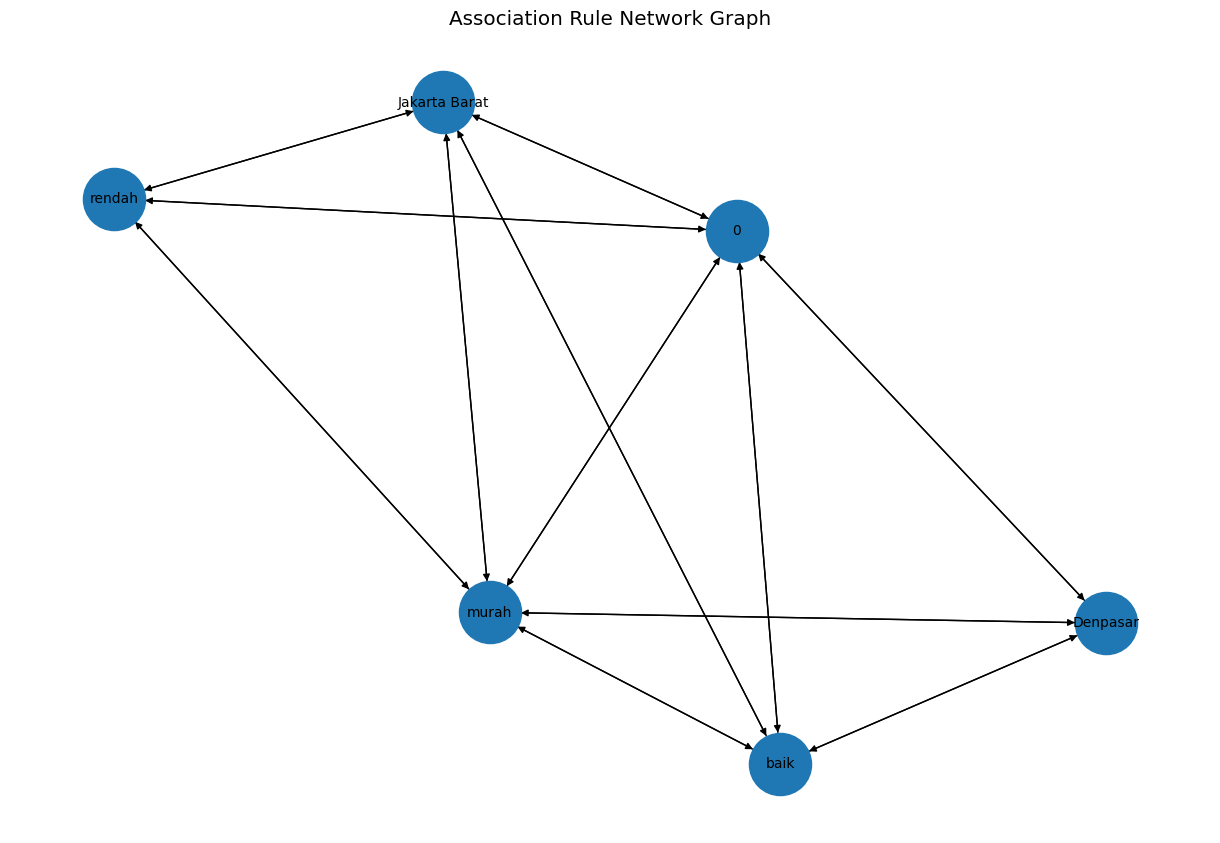

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for _, row in rules_suspicious.iterrows():
    for ant in row['antecedents']:
        for cons in row['consequents']:
            G.add_edge(ant, cons, weight=row['lift'])

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=1)

nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10)
plt.title("Association Rule Network Graph")
plt.show()